# 03 — Inside MACE: Features, Messages and Tensor Products
### A surface science perspective on the MACE architecture

In 01 we trained MACE from scratch for CO/Cu(111).
In 02 we used iterative training, active learning and foundation models.
In this notebook we open the black box:
atomic structure → [embedding → interaction → product → readout] → energy

---

| Section | Topic | Key concept |
|---------|-------|-------------|
| 1 | Spherical harmonics | How atomic directions are encoded |
| 2 | Tensor products | How rotational invariance is guaranteed |
| 3 | Embedding | How species and distances enter the model |
| 4 | Interaction | How neighbours communicate |
| 5 | Product | How many-body descriptors are built |
| 6 | Readout | How features become energies |

In [41]:
# ============================================================
# Installation
# ============================================================
!pip install mace-torch --quiet
!pip install ase --quiet

print("✅ Installation complete")

✅ Installation complete


In [42]:
# ============================================================
# Hardware detection and imports
# ============================================================
import torch
import torch.nn.functional

torch.serialization.add_safe_globals([slice])

from e3nn import o3
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
from mace import data, modules, tools
from mace.tools import torch_geometric
import ase
from ase.build import fcc111
from ase.constraints import FixAtoms
import warnings
warnings.filterwarnings("ignore")

torch.set_default_dtype(torch.float64)

if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"
    print("⚠️  No GPU — using CPU")
    print("   All cells will work but tensor products are slower")

print(f"\n🔧 PyTorch : {torch.__version__}")
print(f"   dtype   : {torch.get_default_dtype()}")

⚠️  No GPU — using CPU
   All cells will work but tensor products are slower

🔧 PyTorch : 2.10.0+cpu
   dtype   : torch.float64


In [43]:
# ============================================================
# CELL 4 — Default MACE model configuration
# ============================================================
from mace import modules, tools
import numpy as np

# Elements: Cu, C, O
z_table         = tools.AtomicNumberTable([6, 8, 29])
atomic_energies = np.array([-3.5, -4.6, -3.51], dtype=float)

cutoff       = 5.0   # same r_max as 01/02
max_ell      = 1     # same max_L as 01/02
num_channels = 8     # reduced from 01's 64 — faster for demonstration

default_model_config = dict(
    # --- Radial basis ---
    r_max                 = cutoff,     # cutoff radius in Å
                                        # same as 01: atoms beyond
                                        # this distance are ignored
    num_bessel            = 8,          # number of Bessel basis functions
                                        # encodes distances → edge features
    num_polynomial_cutoff = 5,          # smoothness of cutoff envelope
                                        # higher = smoother decay to zero

    # --- Angular basis ---
    max_ell               = max_ell,    # max l for spherical harmonics
                                        # max_ell=1 → l=0,1 (4 components)


    # --- Interaction blocks ---
    interaction_cls       = modules.RealAgnosticResidualInteractionBlock,
                                        # layer 2: richer, uses equivariant
                                        # features from layer 1
    interaction_cls_first = modules.RealAgnosticInteractionBlock,
                                        # layer 1: simpler, invariant only

    num_interactions      = 2,          # 2 message passing layers
                                        # = information from 2 hops away

    # --- Feature dimensions ---
    num_elements          = 3,          # C, O, Cu
    hidden_irreps         = o3.Irreps(
        f"{num_channels}x0e "          # invariant channels (l=0)
        f"+ {num_channels}x1o"),        # equivariant channels (l=1)
    MLP_irreps            = o3.Irreps("16x0e"),
                                        # readout MLP width
                                        # 16 hidden units → per-atom energy

    # --- Physical parameters ---
    atomic_energies       = atomic_energies,
                                        # E0 reference energies (eV)
                                        # from EMT isolated atoms (T01)
    avg_num_neighbors     = 32.0,       # average neighbours within cutoff
                                        # used for internal normalisation
                                        # of message magnitudes

    # --- Many-body order ---
    atomic_numbers        = z_table.zs,
    correlation           = 3,          # up to 4-body interactions
                                        # (A⊗A⊗A in the product block)


    # --- Nonlinearity ---
    gate                  = torch.nn.functional.silu,
                                        # SiLU activation
                                        # smooth, works well for MLIPs
)

print(" Model config defined")
print(f"   Elements     : Cu, C, O")
print(f"   r_max        : {cutoff} Å  (same as T01/T02)")
print(f"   max_ell      : {max_ell}   (l=0 and l=1 spherical harmonics)")
print(f"   num_channels : {num_channels}   (reduced from T01's 64 for speed)")
print(f"   correlation  : 3   (up to 4-body interactions)")
print(f"   hidden_irreps: {default_model_config['hidden_irreps']}")

 Model config defined
   Elements     : Cu, C, O
   r_max        : 5.0 Å  (same as T01/T02)
   max_ell      : 1   (l=0 and l=1 spherical harmonics)
   num_channels : 8   (reduced from T01's 64 for speed)
   correlation  : 3   (up to 4-body interactions)
   hidden_irreps: 8x0e+8x1o


In [44]:
# ============================================================
# Build a CO/Cu(111) atomic structure
# ============================================================
from ase.build import fcc111
from ase.constraints import FixAtoms
from ase import Atom
import numpy as np

# Small slab: 2x2 supercell, 3 layers
slab = fcc111('Cu', size=(2, 2, 3), a=3.63, vacuum=8.0, periodic=True)

# Tag surface layer
layer_z = np.sort(np.unique(np.round(slab.positions[:, 2], 1)))
top_z   = layer_z[-1]
tags    = [1 if round(a.position[2], 1) == round(top_z, 1) else 0
           for a in slab]
slab.set_tags(tags)
slab.set_constraint(FixAtoms(
    indices=[a.index for a in slab if a.tag == 0]))

# fcc hollow position for 2x2 cell
a1 = np.array([2.56679762, 0.0])
a2 = np.array([1.28339881, 2.22291194])
fcc_xy = (1/3)*a1 + (1/3)*a2

# Add CO manually at fcc hollow site
surf_z = top_z
slab.append(Atom('C', position=[fcc_xy[0], fcc_xy[1], surf_z + 1.6]))
slab.append(Atom('O', position=[fcc_xy[0], fcc_xy[1], surf_z + 2.75]))

print(f"Structure: {slab.get_chemical_formula()}")
print(f"Atoms    : {len(slab)}")
print(f"\nAtom breakdown:")
for sym in ['Cu', 'C', 'O']:
    n = sum(1 for a in slab if a.symbol == sym)
    print(f"  {sym}: {n}")

c_pos = [a.position for a in slab if a.symbol == 'C'][0]
o_pos = [a.position for a in slab if a.symbol == 'O'][0]
print(f"\nC position: {c_pos.round(3)}")
print(f"O position: {o_pos.round(3)}")
print(f"C-O bond  : {np.linalg.norm(o_pos - c_pos):.3f} Å")

Structure: CCu12O
Atoms    : 14

Atom breakdown:
  Cu: 12
  C: 1
  O: 1

C position: [ 1.283  0.741 13.8  ]
O position: [ 1.283  0.741 14.95 ]
C-O bond  : 1.150 Å


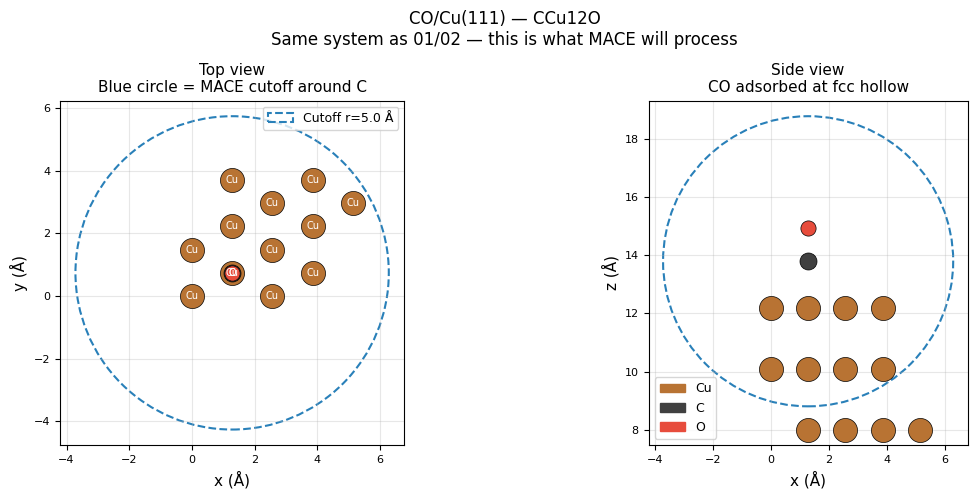

In [45]:
# ============================================================
# Visualise the CO/Cu(111) structure
# Shows which atoms will be connected by edges in MACE
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {'Cu': '#b87333', 'C': '#404040', 'O': '#e74c3c'}
sizes  = {'Cu': 300, 'C': 150, 'O': 120}

# --- Top view ---
ax = axes[0]
for atom in slab:
    ax.scatter(atom.position[0], atom.position[1],
               s=sizes[atom.symbol],
               color=colors[atom.symbol],
               edgecolors='k', linewidths=0.5, zorder=2)
    ax.annotate(atom.symbol,
                (atom.position[0], atom.position[1]),
                fontsize=7, ha='center', va='center',
                color='white' if atom.symbol == 'Cu' else 'white')

# Draw cutoff circle around C atom
c_atom = [a for a in slab if a.symbol == 'C'][0]
circle = plt.Circle((c_atom.position[0], c_atom.position[1]),
                     cutoff, fill=False, color='#2980b9',
                     linestyle='--', linewidth=1.5,
                     label=f'Cutoff r={cutoff} Å')
ax.add_patch(circle)
ax.set_xlabel("x (Å)", fontsize=11)
ax.set_ylabel("y (Å)", fontsize=11)
ax.set_title("Top view\nBlue circle = MACE cutoff around C", fontsize=11)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- Side view ---
ax = axes[1]
for atom in slab:
    ax.scatter(atom.position[0], atom.position[2],
               s=sizes[atom.symbol],
               color=colors[atom.symbol],
               edgecolors='k', linewidths=0.5, zorder=2)

# Draw cutoff sphere around C (cross section)
circle2 = plt.Circle((c_atom.position[0], c_atom.position[2]),
                       cutoff, fill=False, color='#2980b9',
                       linestyle='--', linewidth=1.5)
ax.add_patch(circle2)
ax.set_xlabel("x (Å)", fontsize=11)
ax.set_ylabel("z (Å)", fontsize=11)
ax.set_title("Side view\nCO adsorbed at fcc hollow", fontsize=11)
ax.set_aspect('equal')
ax.grid(alpha=0.3)

patches = [mpatches.Patch(color=colors[s], label=s) for s in colors]
axes[1].legend(handles=patches, fontsize=9)

plt.suptitle(
    f"CO/Cu(111) — {slab.get_chemical_formula()}\n"
    f"Same system as 01/02 — this is what MACE will process",
    fontsize=12
)
plt.tight_layout()
plt.savefig("03_structure.png", dpi=120, bbox_inches='tight')
plt.show()


The dashed circle shows the **cutoff radius** (5.0 Å) around the C atom. Only atoms inside this circle are connected by edges in the MACE graph and exchange messages during the interaction block. With 2 interaction layers, information
can propagate up to 10 Å from any atom.

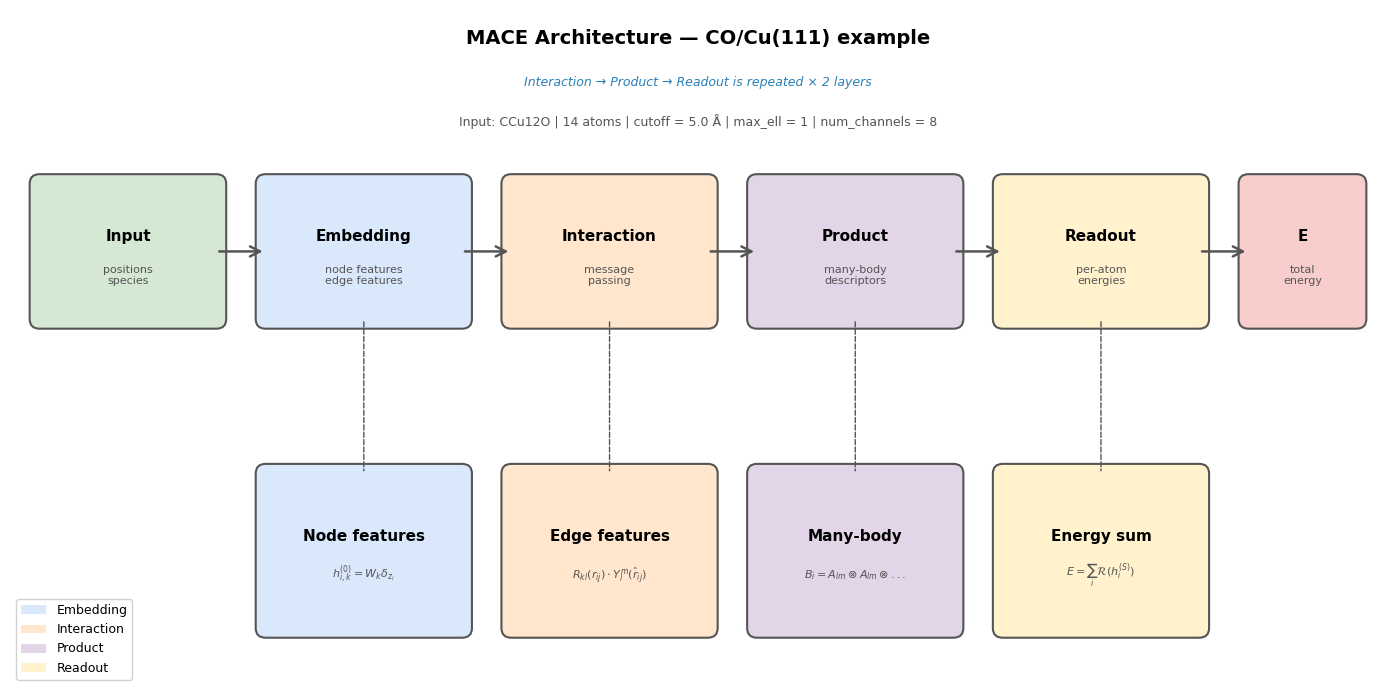

In [46]:
# ============================================================
# CELL 6 — MACE architecture overview
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')

# ── Color scheme ──────────────────────────────────────────────
c_input    = '#d5e8d4'
c_embed    = '#dae8fc'
c_interact = '#ffe6cc'
c_product  = '#e1d5e7'
c_readout  = '#fff2cc'
c_output   = '#f8cecc'
edge_color = '#555555'

def box(ax, x, y, w, h, color, label, sublabel=''):
    rect = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor=edge_color,
        linewidth=1.5, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2 + (0.15 if sublabel else 0),
            label, ha='center', va='center',
            fontsize=11, fontweight='bold', zorder=3)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.25,
                sublabel, ha='center', va='center',
                fontsize=8, color='#555555', zorder=3)

def arrow(ax, x1, x2, y):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(
                    arrowstyle='->', color=edge_color,
                    lw=1.8, mutation_scale=18))

# ── Main pipeline ──────────────────────────────────────────────
y_main = 3.8
box(ax, 0.3,  y_main, 1.8, 1.4, c_input,    'Input',
    'positions\nspecies')
arrow(ax, 2.1, 2.6, y_main + 0.7)

box(ax, 2.6,  y_main, 2.0, 1.4, c_embed,    'Embedding',
    'node features\nedge features')
arrow(ax, 4.6, 5.1, y_main + 0.7)

box(ax, 5.1,  y_main, 2.0, 1.4, c_interact, 'Interaction',
    'message\npassing')
arrow(ax, 7.1, 7.6, y_main + 0.7)

box(ax, 7.6,  y_main, 2.0, 1.4, c_product,  'Product',
    'many-body\ndescriptors')
arrow(ax, 9.6, 10.1, y_main + 0.7)

box(ax, 10.1, y_main, 2.0, 1.4, c_readout,  'Readout',
    'per-atom\nenergies')
arrow(ax, 12.1, 12.6, y_main + 0.7)

box(ax, 12.6, y_main, 1.1, 1.4, c_output,   'E',
    'total\nenergy')

# ── Detail boxes ──────────────────────────────────────────────
y_det = 0.6
details = [
    (2.6,  c_embed,    'Node features',
     r'$h_{i,k}^{(0)} = W_k \delta_{z_i}$'),
    (5.1,  c_interact, 'Edge features',
     r'$R_{kl}(r_{ij}) \cdot Y_l^m(\hat{r}_{ij})$'),
    (7.6,  c_product,  'Many-body',
     r'$B_{i} = A_{lm} \otimes A_{lm} \otimes ...$'),
    (10.1, c_readout,  'Energy sum',
     r'$E = \sum_i \mathcal{R}(h_i^{(S)})$'),
]

for x, color, label, eq in details:
    box(ax, x, y_det, 2.0, 1.6, color, label, eq)
    ax.annotate('', xy=(x + 1.0, y_det + 1.6),
                xytext=(x + 1.0, y_main),
                arrowprops=dict(
                    arrowstyle='-', color=edge_color,
                    lw=1.0, linestyle='dashed'))

# ── Title ──────────────────────────────────────────────────────
ax.text(7.0, 6.7,
        'MACE Architecture — CO/Cu(111) example',
        ha='center', va='center',
        fontsize=14, fontweight='bold')
ax.text(7.0, 6.25,
        'Interaction → Product → Readout is repeated × 2 layers',
        ha='center', va='center',
        fontsize=9, color='#2980b9', style='italic')
ax.text(7.0, 5.85,
        f'Input: {slab.get_chemical_formula()} | '
        f'{len(slab)} atoms | cutoff = {cutoff} Å | '
        f'max_ell = {max_ell} | num_channels = {num_channels}',
        ha='center', va='center',
        fontsize=9, color='#555555')

# ── Legend ─────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=c_embed,    label='Embedding'),
    mpatches.Patch(facecolor=c_interact, label='Interaction'),
    mpatches.Patch(facecolor=c_product,  label='Product'),
    mpatches.Patch(facecolor=c_readout,  label='Readout'),
]
ax.legend(handles=legend_items, loc='lower left',
          fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("03_architecture.png", dpi=150, bbox_inches='tight')
plt.show()

## 1. Spherical Harmonics — Encoding Atomic Directions

### From positions to interactions

MACE starts with atomic positions — just coordinates $(x, y, z)$
for each atom. But to compute energies, it needs to know:

```
1. Who is connected to whom?
   → solved by the cutoff radius: atoms within 5 Å are neighbours

2. How are they connected?
   → the bond vector r̂ᵢⱼ = (rⱼ - rᵢ) / |rⱼ - rᵢ|
   → encodes the direction from atom i to atom j
```

The challenge: how do we encode a 3D direction in a way that
is mathematically well-behaved under rotations?
The answer is **spherical harmonics** $Y_l^m(\hat{r})$.

### Degree and order

Spherical harmonics $Y_l^m$ are controlled by two integers:

- **Degree** $l = 0, 1, 2, ...$ — controls angular frequency.
  Higher $l$ → richer angular description of the bond direction.

- **Order** $m = -l, ..., 0, ..., +l$ — controls orientation.
  For each $l$ there are $2l+1$ values of $m$.

### max_ell — a key hyperparameter

`max_ell` sets the maximum degree used by MACE.
For each $l$, MACE gets $2l+1$ components:

```
l=0  →  1 component   [Y₀⁰]
l=1  →  3 components  [Y₁⁻¹, Y₁⁰, Y₁⁺¹]
l=2  →  5 components  [Y₂⁻², Y₂⁻¹, Y₂⁰, Y₂⁺¹, Y₂⁺²]
```

MACE concatenates all $l$ from 0 up to `max_ell`,
giving $({\tt max\_ell}+1)^2$ components total:

| `max_ell` | Array size | Used in |
|-----------|-----------|---------|
| 1 | $(1+1)^2 = 4$ | 01/02 (our models) |
| 2 | $(2+1)^2 = 9$ | MACE-MP small |
| 3 | $(3+1)^2 = 16$ | MACE-MP large |

Higher `max_ell` → richer angular description → better accuracy,
but training is ~3× slower per step in `max_ell`.
For metal surfaces `max_ell=1` is usually sufficient.

### Equivariance — the key property

### Why do we need rotational symmetry?

The energy of a crystal must not depend on how it is oriented
in space. If you rotate the entire CO/Cu(111) slab by 90°,
the energy must stay exactly the same:

```
E(rotated structure) = E(original structure)
```

This is called **rotational invariance** and it must be built
into MACE by design and it is not learned from data.

### Why the Wigner D-matrix?

When you rotate the input vector $\hat{r} \rightarrow R\hat{r}$,
the spherical harmonics do not simply scale. They **mix with
each other** within the same degree $l$:

$$Y_l^m(R\hat{r}) = \sum_{m'} D_{mm'}^l(R)\ Y_l^{m'}(\hat{r})$$

The **Wigner D-matrix** $D^l(R)$ is the exact mathematical
description of how the $2l+1$ components of degree $l$ mix
under rotation $R$. It is the representation of the rotation
group SO(3) at degree $l$.

Wigner D-matrix is simply the generalisation of the familiar 3D rotation matrix to higher degrees $l$. This is useful because:

```
If we know how each array transforms
→ we can combine arrays in ways that cancel the rotation
→ the result is guaranteed to be invariant
→ no matter what rotation R is applied
```

The $l=0$ component is special:

$$D^0(R) = 1 \quad \text{for any rotation } R$$

So $Y_0^0$ never changes — it is always invariant.
All other $l > 0$ components change, but predictably.

> MACE tracks the D-matrix transformation of every array
> throughout the network. The tensor products in the Product
> block are designed to combine equivariant arrays into
> invariant outputs. This guarantees rotational invariance
> of the final energy — without ever explicitly applying
> or checking rotations.

In [47]:
# ============================================================
# Compute spherical harmonics on a real Cu-C bond
# Using the actual CO/Cu(111) structure from Cell 4
# ============================================================
from e3nn import o3
import torch
import numpy as np

# --- Set up spherical harmonics for l=0,1,2 ---
# normalize=True: normalises so integral over sphere = 1
spherical_harmonics = o3.SphericalHarmonics(
    irreps_out=[0, 1, 2],
    normalize=True,
    normalization='component'
)

# --- Get the C atom and its nearest Cu neighbour ---
c_atom  = [a for a in slab if a.symbol == 'C'][0]
cu_atoms = [a for a in slab if a.symbol == 'Cu']

# Find nearest Cu to C
dists   = [np.linalg.norm(a.position - c_atom.position)
           for a in cu_atoms]
nearest = cu_atoms[np.argmin(dists)]
dist_CO = np.min(dists)

# Bond vector C → nearest Cu (unit vector)
r_vec   = nearest.position - c_atom.position
r_hat   = r_vec / np.linalg.norm(r_vec)

print(f"C  position : {c_atom.position.round(3)}")
print(f"Cu position : {nearest.position.round(3)}")
print(f"Bond length : {dist_CO:.3f} Å")
print(f"Unit vector : {r_hat.round(4)}")

# --- Compute Ylm ---
r_tensor = torch.tensor(r_hat, dtype=torch.float64)
ylm      = spherical_harmonics(r_tensor)

print(f"\nSpherical harmonics Y_lm for Cu-C bond direction:")
print(f"  Array shape : {ylm.shape}  (l=0,1,2 → 1+3+5=9 components)")
print(f"\n  l=0: Y_0^0         = {ylm[0].item():+.4f}  (constant, invariant)")
print(f"  l=1: Y_1^(-1,0,1)  = {ylm[1].item():+.4f}, "
      f"{ylm[2].item():+.4f}, {ylm[3].item():+.4f}")
print(f"  l=2: Y_2^(-2,...,2)= "
      f"{', '.join([f'{ylm[i].item():+.4f}' for i in range(4,9)])}")

print(f"\nNote: l=0 component is always {ylm[0].item():.4f}")
print(f"      regardless of direction — it carries no angular info")

C  position : [ 1.283  0.741 13.8  ]
Cu position : [ 2.567  0.    12.192]
Bond length : 2.187 Å
Unit vector : [ 0.5868 -0.3388 -0.7354]

Spherical harmonics Y_lm for Cu-C bond direction:
  Array shape : torch.Size([9])  (l=0,1,2 → 1+3+5=9 components)

  l=0: Y_0^0         = +1.0000  (constant, invariant)
  l=1: Y_1^(-1,0,1)  = +1.0164, -0.5868, -1.2738
  l=2: Y_2^(-2,...,2)= -1.6714, -0.7700, -0.7330, +0.9650, +0.3805

Note: l=0 component is always 1.0000
      regardless of direction — it carries no angular info


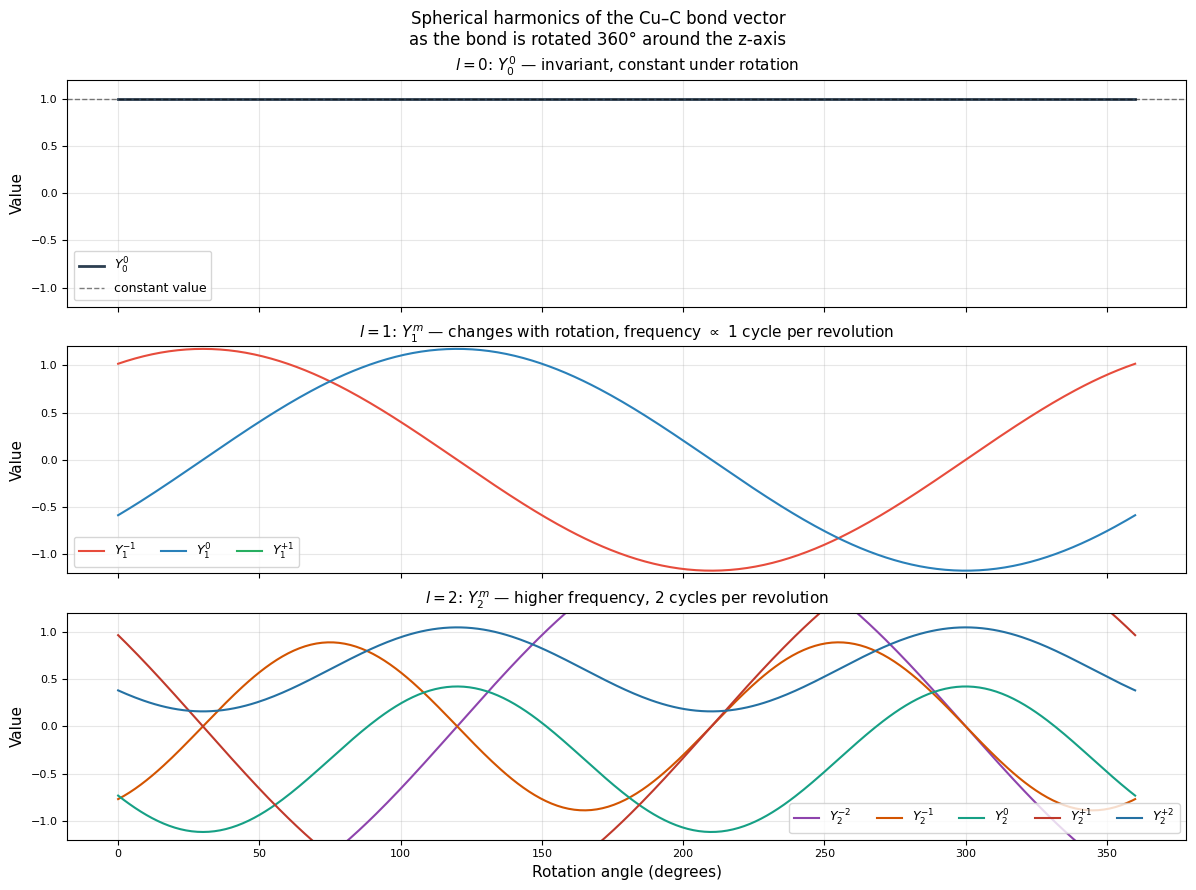


Key observation:
  l=0: flat line → no angular information
  l=1: 1 oscillation per 360° → dipole-like
  l=2: 2 oscillations per 360° → quadrupole-like

Higher l → richer angular description → better MACE accuracy
01/02 used max_ell=1 → up to l=1 components only


In [48]:
# ============================================================
# How Ylm components change as the bond rotates
# Rotate the Cu-C bond vector 360° and track each component
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial.transform import Rotation

# Rotate the Cu-C bond vector 360° around z-axis
N = 360
angles = np.linspace(0, 360, N)
ylm_values = []


# Here, we rotate the bond vector directly (R @ r_hat)
# rather than applying the Wigner D-matrix explicitly.
# The two approaches are mathematically equivalent.
for angle in angles:
    R = Rotation.from_rotvec( # standard 3×3 rotation matrix
        angle * np.pi / 180 * np.array([0, 0, 1])
    ).as_matrix()
    r_rotated = R @ r_hat  # rotate the bond vector
    r_tensor  = torch.tensor(r_rotated, dtype=torch.float64)
    ylm       = spherical_harmonics(r_tensor) # compute Ylm on rotated vector
    ylm_values.append(ylm.detach().numpy())

ylm_values = np.array(ylm_values)

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

colors_l0 = ['#2c3e50']
colors_l1 = ['#e74c3c', '#2980b9', '#27ae60']
colors_l2 = ['#8e44ad', '#d35400', '#16a085', '#c0392b', '#2471a3']

# l=0
ax = axes[0]
ax.plot(angles, ylm_values[:, 0],
        color=colors_l0[0], linewidth=2.0,
        label=r'$Y_0^0$')
ax.axhline(ylm_values[0, 0], color='k', linestyle='--',
           linewidth=1.0, alpha=0.5, label='constant value')
ax.set_ylabel("Value", fontsize=11)
ax.set_title(
    r"$l=0$: $Y_0^0$ — invariant, constant under rotation",
    fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(-1.2, 1.2)

# l=1
ax = axes[1]
labels_l1 = [r'$Y_1^{-1}$', r'$Y_1^{0}$', r'$Y_1^{+1}$']
for i, (col, lab) in enumerate(zip(colors_l1, labels_l1)):
    ax.plot(angles, ylm_values[:, 1+i],
            color=col, linewidth=1.5, label=lab)
ax.set_ylabel("Value", fontsize=11)
ax.set_title(
    r"$l=1$: $Y_1^m$ — changes with rotation, "
    r"frequency $\propto$ 1 cycle per revolution",
    fontsize=11)
ax.legend(fontsize=9, ncol=3)
ax.grid(alpha=0.3)
ax.set_ylim(-1.2, 1.2)

# l=2
ax = axes[2]
labels_l2 = [r'$Y_2^{-2}$', r'$Y_2^{-1}$',
             r'$Y_2^{0}$',  r'$Y_2^{+1}$', r'$Y_2^{+2}$']
for i, (col, lab) in enumerate(zip(colors_l2, labels_l2)):
    ax.plot(angles, ylm_values[:, 4+i],
            color=col, linewidth=1.5, label=lab)
ax.set_xlabel("Rotation angle (degrees)", fontsize=11)
ax.set_ylabel("Value", fontsize=11)
ax.set_title(
    r"$l=2$: $Y_2^m$ — higher frequency, "
    r"2 cycles per revolution",
    fontsize=11)
ax.legend(fontsize=9, ncol=5)
ax.grid(alpha=0.3)
ax.set_ylim(-1.2, 1.2)

plt.suptitle(
    "Spherical harmonics of the Cu–C bond vector\n"
    "as the bond is rotated 360° around the z-axis",
    fontsize=12
)
plt.tight_layout()
plt.savefig("T03_spherical_harmonics.png",
            dpi=120, bbox_inches='tight')
plt.show()
print(f"\nKey observation:")
print(f"  l=0: flat line → no angular information")
print(f"  l=1: 1 oscillation per 360° → dipole-like")
print(f"  l=2: 2 oscillations per 360° → quadrupole-like")
print(f"\nHigher l → richer angular description → better MACE accuracy")
print(f"01/02 used max_ell=1 → up to l=1 components only")

## 2. Tensor Products — Getting Invariant Quantities

### The problem

We need quantities that are:

```
 Invariant to global rotations  (rotating the crystal must not change the energy)
 Sensitive to local geometry     (the angle between two bonds must affect the energy)
```

The $l=0$ spherical harmonic is invariant but useless. It is the same constant (+1.0) for every bond direction. It carries no geometric information at all.

The $l=1$ components carry geometric information but are **not** invariant. They change when you rotate the crystal.

So neither works alone. We need to **combine** them.

### The solution — tensor products

Take two bond vectors $\hat{r}_1$ and $\hat{r}_2$ from the
same atom (say, two Cu neighbours of the C atom).
Compute their spherical harmonics and **multiply** them
in a specific way:

$$\left(Y^{l_1}(\hat{r}_1) \otimes Y^{l_2}(\hat{r}_2)\right)^{L=0}
= \sum_{m_1 m_2} C^{00}_{l_1 m_1 l_2 m_2}
\ Y^{l_1}_{m_1}(\hat{r}_1)\ Y^{l_2}_{m_2}(\hat{r}_2)$$

The output with $L=0$ is:

```
✅ Invariant — if you rotate both bonds by the same R, the output does not change
✅ Geometric  — if you change the angle between the bonds, the output changes
```

### What are the Clebsch-Gordan coefficients?

The coefficients $C^{LM}_{l_1 m_1 l_2 m_2}$ are fixed numbers
— not learned — that specify exactly how to combine the
components to guarantee the output transforms correctly.

If you have studied quantum mechanics: these are the same
coefficients used to add angular momenta $j_1 \otimes j_2$.
The mathematics is identical. If you have not: think of them as a recipe that tells you which components to multiply and how to sum them so that
rotations cancel out in the result.

The `e3nn` library computes all these coefficients
automatically.

### Selection rules

Not all output degrees $L$ are non-zero. The allowed values are:

$$|l_1 - l_2| \leq L \leq l_1 + l_2$$

For $l_1 = l_2 = 1$: allowed $L = 0, 1, 2$.
Only $L=0$ gives a **rotationally invariant** output.
$L=1$ and $L=2$ outputs are equivariant. They change
under rotations but in a controlled way, useful for
passing information between layers.

### In MACE

MACE applies this operation repeatedly, once per pair
of neighbour features per atom per layer,  building up
increasingly rich many-body invariants. The `e3nn` library
handles all the Clebsch-Gordan bookkeeping automatically.

In [49]:
# ============================================================
# Tensor product of two bond directions
# Using two real bonds from the CO/Cu(111) structure
# ============================================================
from e3nn import o3
import torch
import numpy as np

# --- Get two Cu neighbours of the C atom ---
c_pos   = c_atom.position
cu_atoms = [a for a in slab if a.symbol == 'Cu']
dists   = [(np.linalg.norm(a.position - c_pos), a)
           for a in cu_atoms]
dists.sort(key=lambda x: x[0])

# Two nearest Cu neighbours
r1 = dists[0][1].position - c_pos
r2 = dists[1][1].position - c_pos
r1_hat = r1 / np.linalg.norm(r1)
r2_hat = r2 / np.linalg.norm(r2)

angle_between = np.degrees(
    np.arccos(np.clip(np.dot(r1_hat, r2_hat), -1, 1)))

print(f"Bond 1 (C→Cu): length={np.linalg.norm(r1):.3f} Å")
print(f"Bond 2 (C→Cu): length={np.linalg.norm(dists[1][0]):.3f} Å")
print(f"Angle between : {angle_between:.2f}°")

# --- Compute Ylm for both bonds ---
# coordinates to spherical harmonics
sph = o3.SphericalHarmonics([0,1,2], normalize=True,
                             normalization='component')

ylm1 = sph(torch.tensor(r1_hat, dtype=torch.float64))
ylm2 = sph(torch.tensor(r2_hat, dtype=torch.float64))

# --- Set up tensor product → 3 invariant (L=0) outputs ---
# tensor product with L=0
tp = o3.FullyConnectedTensorProduct(
    irreps_in1=o3.Irreps("1x0e + 1x1o + 1x2e"),
    irreps_in2=o3.Irreps("1x0e + 1x1o + 1x2e"),
    irreps_out=o3.Irreps("3x0e"),
    internal_weights=False
)
print(f"\nTensor product: {tp}")
print(f"Number of weights: {tp.weight_numel}")

# --- Compute invariant product ---
weights = torch.ones(tp.weight_numel, dtype=torch.float64)
product = tp(
    ylm1.unsqueeze(0),
    ylm2.unsqueeze(0),
    weights
)
print(f"\nInvariant outputs (L=0): {product.detach().numpy().round(4)}")
print(f"Shape: {product.shape}  ← 3 invariant numbers")

Bond 1 (C→Cu): length=2.187 Å
Bond 2 (C→Cu): length=2.187 Å
Angle between : 71.86°

Tensor product: FullyConnectedTensorProduct(1x0e+1x1o+1x2e x 1x0e+1x1o+1x2e -> 3x0e | 9 paths | 9 weights)
Number of weights: 9

Invariant outputs (L=0): [[0.4308 0.4308 0.4308]]
Shape: torch.Size([1, 3])  ← 3 invariant numbers


In [50]:
# ============================================================
# Prove the tensor product is rotation-invariant
# Rotate both bonds by the same rotation → output unchanged
# ============================================================
from scipy.spatial.transform import Rotation as R
import torch
import numpy as np

print("Rotating BOTH bond vectors by the same random rotation")
print("and checking the tensor product output stays the same:\n")

print(f"{'Rotation':>25}  {'Output[0]':>10}  {'Output[1]':>10}  {'Output[2]':>10}")
print("─" * 65)

# Original (no rotation)
product_orig = product.detach().numpy()[0]
print(f"{'Original (0°)':>25}  "
      f"{product_orig[0]:>10.4f}  "
      f"{product_orig[1]:>10.4f}  "
      f"{product_orig[2]:>10.4f}")

# Several random rotations
test_rotations = [
    ("z-axis 45°",   [0, 0, 1],    45),
    ("x-axis 133°",  [1, 0, 0],   133),
    ("random 77.7°", [0, 0.7071, 0.7071], 77.7),
    ("random 200°",  [0.5, 0.5, 0.7071], 200),
]

for name, axis, angle in test_rotations:
    rot_mat = R.from_rotvec(
        np.radians(angle) * np.array(axis)
    ).as_matrix()

    r1_rot = rot_mat @ r1_hat
    r2_rot = rot_mat @ r2_hat

    ylm1_rot = sph(torch.tensor(r1_rot, dtype=torch.float64))
    ylm2_rot = sph(torch.tensor(r2_rot, dtype=torch.float64))

    prod_rot = tp(
        ylm1_rot.unsqueeze(0),
        ylm2_rot.unsqueeze(0),
        weights
    ).detach().numpy()[0]

    print(f"{name:>25}  "
          f"{prod_rot[0]:>10.4f}  "
          f"{prod_rot[1]:>10.4f}  "
          f"{prod_rot[2]:>10.4f}")

print("\n All outputs identical — tensor product is rotation-invariant")
print("   This is the mathematical guarantee that MACE energies")
print("   do not depend on the orientation of the crystal in space")

Rotating BOTH bond vectors by the same random rotation
and checking the tensor product output stays the same:

                 Rotation   Output[0]   Output[1]   Output[2]
─────────────────────────────────────────────────────────────────
            Original (0°)      0.4308      0.4308      0.4308
               z-axis 45°      0.4308      0.4308      0.4308
              x-axis 133°      0.4308      0.4308      0.4308
             random 77.7°      0.4308      0.4308      0.4308
              random 200°      0.4308      0.4308      0.4308

 All outputs identical — tensor product is rotation-invariant
   This is the mathematical guarantee that MACE energies
   do not depend on the orientation of the crystal in space


In [51]:
# ============================================================
# Data preparation: atoms → graph
# Convert the CO/Cu(111) slab into MACE's internal format
# nodes = atoms, edges = pairs within cutoff radius
# ============================================================
from mace import data, tools
import numpy as np
import torch

# --- Build MACE graph from our slab ---
z_table = tools.AtomicNumberTable([6, 8, 29])  # C, O, Cu

config = data.Configuration(
    atomic_numbers = slab.numbers,
    positions      = slab.positions,
    properties     = {},
    property_weights = {},
)

batch = data.AtomicData.from_config(
    config, z_table=z_table, cutoff=cutoff)

print("=== MACE Graph Representation ===\n")
print(f"Nodes (atoms): {batch.positions.shape[0]}")
print(f"Edges (bonds within {cutoff} Å): {batch.edge_index.shape[1]}")
print(f"\nnode_attrs shape : {batch.node_attrs.shape}")
print(f"  → one-hot encoding: [C, O, Cu]")
print(f"\nFirst 5 node_attrs (one row per atom):")
species = ['C', 'O', 'Cu']
for i in range(min(5, len(slab))):
    idx  = batch.node_attrs[i].argmax().item()
    print(f"  Atom {i} ({slab[i].symbol}): {batch.node_attrs[i].numpy()} "
          f"→ {species[idx]}")

print(f"\nedge_index shape : {batch.edge_index.shape}")
print(f"  → row 0 = sender atom index")
print(f"  → row 1 = receiver atom index")
print(f"\nFirst 5 edges:")
for i in range(5):
    s = batch.edge_index[0, i].item()
    r = batch.edge_index[1, i].item()
    print(f"  Edge {i}: {slab[s].symbol}({s}) → {slab[r].symbol}({r})")

=== MACE Graph Representation ===

Nodes (atoms): 14
Edges (bonds within 5.0 Å): 136

node_attrs shape : torch.Size([14, 3])
  → one-hot encoding: [C, O, Cu]

First 5 node_attrs (one row per atom):
  Atom 0 (Cu): [0. 0. 1.] → Cu
  Atom 1 (Cu): [0. 0. 1.] → Cu
  Atom 2 (Cu): [0. 0. 1.] → Cu
  Atom 3 (Cu): [0. 0. 1.] → Cu
  Atom 4 (Cu): [0. 0. 1.] → Cu

edge_index shape : torch.Size([2, 136])
  → row 0 = sender atom index
  → row 1 = receiver atom index

First 5 edges:
  Edge 0: Cu(0) → Cu(1)
  Edge 1: Cu(0) → Cu(2)
  Edge 2: Cu(0) → Cu(3)
  Edge 3: Cu(0) → Cu(4)
  Edge 4: Cu(0) → Cu(5)


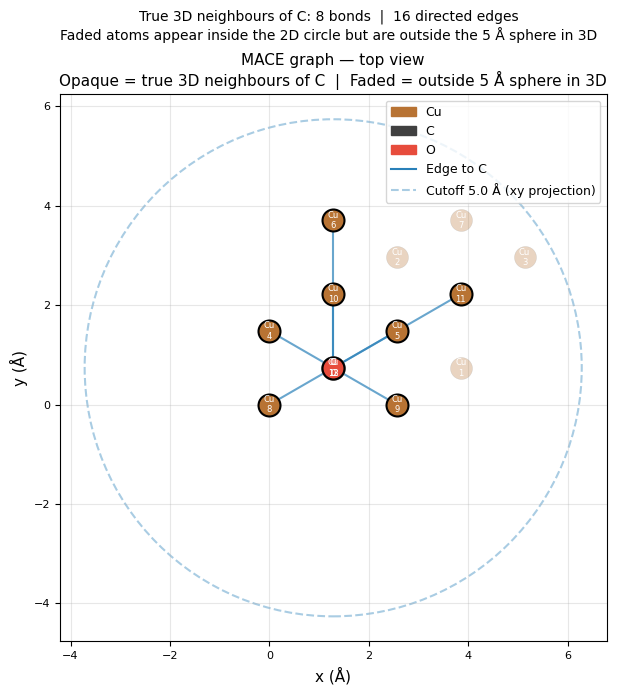

In [52]:
# ============================================================
# CELL 14 — Visualise the MACE graph
# Shows which atoms are TRUE 3D neighbours of C
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

fig, ax = plt.subplots(figsize=(8, 7))

colors = {'Cu': '#b87333', 'C': '#404040', 'O': '#e74c3c'}
sizes  = {'Cu': 250, 'C': 300, 'O': 250}

# Find C atom and its true 3D neighbours
c_idx = [a.index for a in slab if a.symbol == 'C'][0]
c_pos = slab[c_idx].position

c_neighbours = []
for i in range(batch.edge_index.shape[1]):
    s = batch.edge_index[0, i].item()
    r = batch.edge_index[1, i].item()
    if r == c_idx and s != c_idx:
        d3d = np.linalg.norm(slab[s].position - c_pos)
        c_neighbours.append((s, d3d))

neighbour_indices = set(s for s, d in c_neighbours)

# --- Draw atoms ---
for atom in slab:
    is_neighbour = atom.index in neighbour_indices
    ax.scatter(atom.position[0], atom.position[1],
               s=sizes[atom.symbol],
               color=colors[atom.symbol],
               edgecolors='k' if is_neighbour else 'grey',
               linewidths=1.5 if is_neighbour else 0.3,
               alpha=1.0 if is_neighbour or
               atom.symbol in ['C', 'O'] else 0.3,
               zorder=3)
    ax.text(atom.position[0], atom.position[1],
            f"{atom.symbol}\n{atom.index}",
            ha='center', va='center',
            fontsize=6, color='white', zorder=4)

# --- Draw edges from C to true 3D neighbours ---
for s, d in c_neighbours:
    ax.plot([c_pos[0], slab[s].position[0]],
            [c_pos[1], slab[s].position[1]],
            color='#2980b9', linewidth=1.5,
            alpha=0.7, zorder=2)

# --- Cutoff circle (xy projection) ---
circle = plt.Circle((c_pos[0], c_pos[1]), cutoff,
                     fill=False, color='#2980b9',
                     linestyle='--', linewidth=1.5,
                     alpha=0.4)
ax.add_patch(circle)

ax.set_xlabel("x (Å)", fontsize=11)
ax.set_ylabel("y (Å)", fontsize=11)
ax.set_title(
    "MACE graph — top view\n"
    "Opaque = true 3D neighbours of C  |  "
    "Faded = outside 5 Å sphere in 3D",
    fontsize=11)
ax.set_aspect('equal')
ax.grid(alpha=0.3)

# --- Legend ---
patches = [mpatches.Patch(color=colors[s], label=s)
           for s in ['Cu', 'C', 'O']]
patches.append(mlines.Line2D([0], [0], color='#2980b9',
               linewidth=1.5, label='Edge to C'))
patches.append(mlines.Line2D([0], [0], color='#2980b9',
               linewidth=1.5, linestyle='--',
               alpha=0.4,
               label=f'Cutoff {cutoff} Å (xy projection)'))
ax.legend(handles=patches, fontsize=9, loc='upper right')

plt.suptitle(
    f"True 3D neighbours of C: {len(c_neighbours)} bonds  |  "
    f"{len(c_neighbours)*2} directed edges\n"
    f"Faded atoms appear inside the 2D circle but are "
    f"outside the 5 Å sphere in 3D",
    fontsize=10
)
plt.tight_layout()
plt.savefig("03_graph.png", dpi=120, bbox_inches='tight')
plt.show()


## 3. Embedding — Initial Node and Edge Features

### What MACE needs as input

MACE represents the atomic structure as a graph:
- **Nodes** = atoms
- **Edges** = bonds between atoms within the cutoff

For each node and edge, MACE needs to encode three things:

```
1. What is the atom?          → node features
2. How far apart are they?    → edge features (distance)
3. In which direction?        → edge attributes (direction)
```

---

### 1. Node features — what kind of atom?

Each atom gets an initial feature vector based **only on its species**:

$$h_{i,k}^{(0)} = \sum_z W_{kz}\ \delta_{z,z_i}$$

In plain words: Cu always gets the same initial vector,
C always gets the same initial vector, O always gets the same.
The environment does not matter yet. That comes later
in the Interaction block when neighbours exchange messages.

$W_{kz}$ is a learnable matrix of shape (num_channels, num_elements)
— optimised during training.

---

### 2. Edge features — how far apart?

Distances $r_{ij}$ are encoded using **Bessel basis functions**:

$$e_{ij,n} = \sqrt{\frac{2}{r_c}}\ \frac{\sin(n\pi r_{ij}/r_c)}{r_{ij}}\ f_\text{cut}(r_{ij})$$

Why Bessel functions and not just the raw distance $r_{ij}$?

```
Raw distance: one number → very little information
Bessel basis: num_bessel smooth functions of distance
              → richer encoding of the distance
              → all go smoothly to zero at the cutoff
              (no discontinuity when atoms enter/leave
                 the neighbour list)
```

These fixed Bessel values are then passed through a
**learnable radial MLP** which produces $R_{kl}(r_{ij})$ —
one learned radial function per (channel, l) combination.
This is what gets optimised during training.

---

### 3. Edge attributes — in which direction?

Directions $\hat{r}_{ij}$ are encoded as spherical harmonics
$Y_l^m(\hat{r}_{ij})$ — exactly what we computed in Section 1.

```
Note: edge attributes are NOT passed through any MLP.
They enter the tensor product directly — fixed mathematical
functions of the bond direction, not learned.

The spherical harmonics carry the rotational symmetry information.
Passing them through an MLP would break the equivariance guarantee.
```

---

| Input | Encodes | Learnable? |
|-------|---------|-----------|
| Node features $h_i^{(0)}$ | Species (Cu, C, O) | ✅ Yes ($W_{kz}$) |
| Edge features $e_{ij}$ | Distance $r_{ij}$ | ✅ Yes (radial MLP) |
| Edge attributes $Y_{ij}$ | Direction $\hat{r}_{ij}$ | ❌ No (fixed math) |

In [53]:
# ============================================================
# Compute initial embeddings for our CO/Cu(111) slab
# ============================================================
from mace import modules
import torch
import numpy as np

# --- Build a small MACE model ---
model = modules.MACE(**default_model_config)
print(f"MACE model built")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

# --- Get edge vectors and lengths first ---
vectors, lengths = modules.utils.get_edge_vectors_and_lengths(
    positions  = batch.positions,
    edge_index = batch.edge_index,
    shifts     = batch.shifts,
)

# --- Compute all three embeddings ---
# 1. Node features from species
initial_node_feats = model.node_embedding(batch.node_attrs)

# 2. Edge features from distances (Bessel basis → radial MLP)
edge_feats, _ = model.radial_embedding(
    lengths,
    batch.node_attrs,
    batch.edge_index,
    model.atomic_numbers
)

# 3. Edge attributes from directions (spherical harmonics)
edge_attrs = model.spherical_harmonics(vectors)

print(f"\n=== Embedding shapes ===")
print(f"node_features  : {tuple(initial_node_feats.shape)}"
      f"  → (N_atoms={len(slab)}, num_channels={num_channels})")
print(f"edge_features  : {tuple(edge_feats.shape)}"
      f"  → (N_edges={batch.edge_index.shape[1]}, num_bessel=8)")
print(f"edge_attributes: {tuple(edge_attrs.shape)}"
      f"  → (N_edges, (max_ell+1)²={(max_ell+1)**2})")

# --- Show node features per species ---
print(f"\n=== Node features by species ===")
print(f"(untrained — random weights)")
for sym, z in [('C', 6), ('O', 8), ('Cu', 29)]:
    idx = [i for i, a in enumerate(slab) if a.symbol == sym]
    if idx:
        feats = initial_node_feats[idx[0]].detach().numpy()
        print(f"  {sym}: min={feats.min():.3f}  "
              f"max={feats.max():.3f}  "
              f"mean={feats.mean():.3f}")

MACE model built
  Parameters: 22,552

=== Embedding shapes ===
node_features  : (14, 8)  → (N_atoms=14, num_channels=8)
edge_features  : (136, 8)  → (N_edges=136, num_bessel=8)
edge_attributes: (136, 4)  → (N_edges, (max_ell+1)²=4)

=== Node features by species ===
(untrained — random weights)
  C: min=-1.140  max=1.554  mean=-0.007
  O: min=-1.632  max=1.162  mean=-0.010
  Cu: min=-0.917  max=0.499  mean=-0.161


**Node features: (14, 8)**
```
14 atoms × 8 channels
Each atom gets a vector of 8 numbers encoding its species.
All Cu atoms get the same 8 numbers (before interaction).
C and O get different 8 numbers from each other and from Cu.

Image:   each pixel has 3 channels [R, G, B]
         each channel encodes a different property of the pixel

MACE:    each atom has 8 channels [h₀, h₁, h₂, ..., h₇]
         each channel learns to encode a different property
         of the atom's chemical environment
```

**Edge features: (136, 8)**
```
136 directed edges × 8 Bessel basis functions
Each bond distance is encoded as 8 smooth Bessel values.
136 = 8 bonds × 2 directions × number of periodic images
```

**Edge attributes: (136, 4)**
```
136 directed edges × 4 spherical harmonic components
4 = (max_ell+1)² = (1+1)² → l=0 (1 value) + l=1 (3 values)
Each bond direction encoded as 4 fixed Ylm values.
```

**Node features by species (untrained):**
```
C : mean= 0.124  (random — will shift after training)
O : mean= 0.278  (different from C and Cu )
Cu: mean= 0.035  (closest to zero — most abundant species)
```

The values are random because the model is untrained.
After training on 01/02 data, these initial embeddings
would reflect the actual chemical identity of each species —
C and O would have very different feature vectors from Cu,
encoding their different roles as adsorbate vs metal.

Radial MLP output shape: (136, 16)
  → (N_edges=136, N_weights=16)


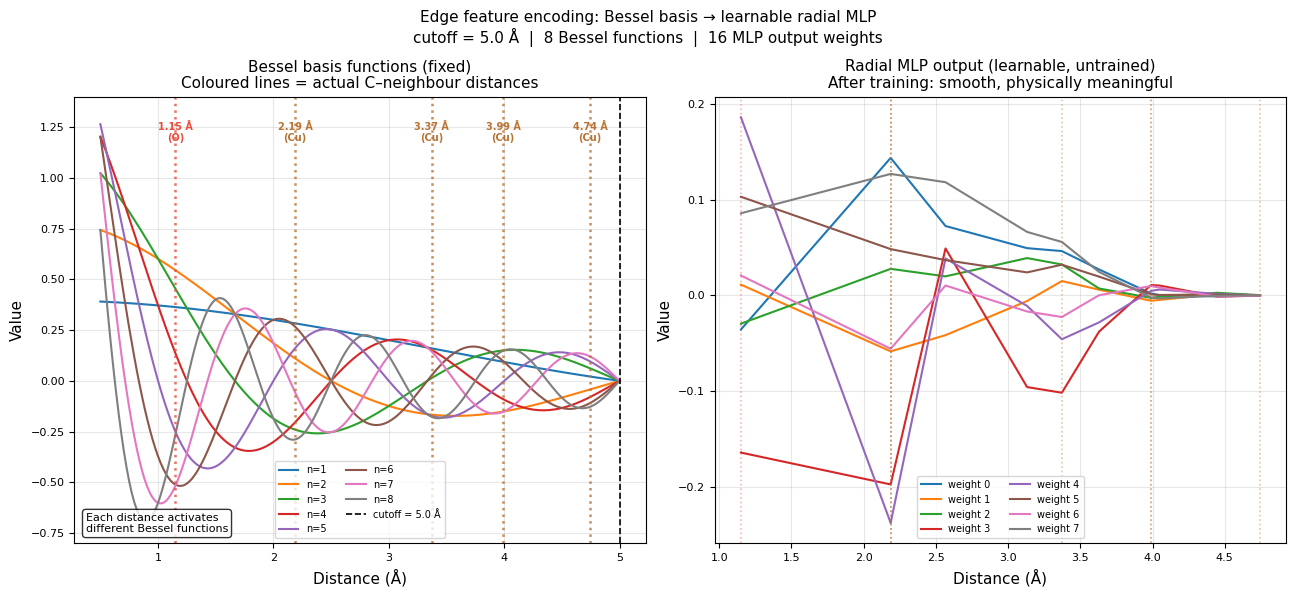

In [54]:
# ============================================================
# Visualise edge features (Bessel basis + radial MLP)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import torch
from mace.modules.radial import BesselBasis, PolynomialCutoff

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- Bessel basis setup ---
bessel     = BesselBasis(r_max=cutoff, num_basis=8)
dists_scan = torch.linspace(0.5, cutoff, 200,
                             dtype=torch.float64).unsqueeze(-1)
bessel_vals = bessel(dists_scan).detach().numpy()

# --- Get actual C-neighbour distances ---
c_idx      = [a.index for a in slab if a.symbol == 'C'][0]
edge_dists = lengths.detach().numpy().flatten()

c_distances = []
for i in range(batch.edge_index.shape[1]):
    s = batch.edge_index[0, i].item()
    r = batch.edge_index[1, i].item()
    if r == c_idx:
        c_distances.append((edge_dists[i], slab[s].symbol))

# ── Panel 1: Bessel basis ──────────────────────────────────────
ax = axes[0]
for i in range(bessel_vals.shape[1]):
    ax.plot(dists_scan.numpy(), bessel_vals[:, i],
            linewidth=1.5, label=f'n={i+1}')

ax.axvline(cutoff, color='k', linestyle='--',
           linewidth=1.2, label=f'cutoff = {cutoff} Å')

# Mark actual bond distances with coloured vertical lines
colors_bond = {'Cu': '#b87333', 'O': '#e74c3c'}
plotted = set()
for d, sym in sorted(c_distances):
    d_round = round(d, 2)
    if d_round not in plotted:
        ax.axvline(d, color=colors_bond.get(sym, 'grey'),
                   alpha=0.8, linewidth=1.8, linestyle=':')
        ax.text(d, 1.18, f'{d:.2f} Å\n({sym})',
                ha='center', fontsize=7,
                color=colors_bond.get(sym, 'grey'),
                fontweight='bold')
        plotted.add(d_round)

ax.set_ylim(-0.8, 1.4)
ax.set_xlabel("Distance (Å)", fontsize=11)
ax.set_ylabel("Value", fontsize=11)
ax.set_title("Bessel basis functions (fixed)\n"
             "Coloured lines = actual C–neighbour distances",
             fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

# Add annotation explaining the pattern
ax.text(0.02, 0.02,
        "Each distance activates\ndifferent Bessel functions",
        transform=ax.transAxes, fontsize=8,
        va='bottom',
        bbox=dict(boxstyle='round', facecolor='white',
                  alpha=0.8))

# ── Panel 2: Radial MLP output ────────────────────────────────
ax = axes[1]
edge_feats_scan, _ = model.radial_embedding(
    lengths,
    batch.node_attrs,
    batch.edge_index,
    model.atomic_numbers
)

tp_weights = model.interactions[0].conv_tp_weights(
    edge_feats_scan
).detach().numpy()

print(f"Radial MLP output shape: {tp_weights.shape}")
print(f"  → (N_edges={tp_weights.shape[0]}, "
      f"N_weights={tp_weights.shape[1]})")

sort_idx = np.argsort(edge_dists)
for i in range(min(8, tp_weights.shape[1])):
    ax.plot(edge_dists[sort_idx],
            tp_weights[sort_idx, i],
            linewidth=1.5, label=f'weight {i}')

# Mark actual bond distances on MLP panel too
for d, sym in sorted(c_distances):
    d_round = round(d, 2)
    if d_round not in set():
        ax.axvline(d, color=colors_bond.get(sym, 'grey'),
                   alpha=0.4, linewidth=1.2, linestyle=':')

ax.set_xlabel("Distance (Å)", fontsize=11)
ax.set_ylabel("Value", fontsize=11)
ax.set_title("Radial MLP output (learnable, untrained)\n"
             "After training: smooth, physically meaningful",
             fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

plt.suptitle(
    "Edge feature encoding: Bessel basis → learnable radial MLP\n"
    f"cutoff = {cutoff} Å  |  8 Bessel functions  |  "
    f"{tp_weights.shape[1]} MLP output weights",
    fontsize=11
)
plt.tight_layout()
plt.savefig("03_radial.png", dpi=120, bbox_inches='tight')
plt.show()

**Left — Bessel basis functions (fixed):**
8 smooth functions of distance, all going to zero at 5 Å.
They convert one number (bond distance) into 8 numbers —
a richer representation than the raw distance alone.
The grey lines mark the actual Cu–C bond distances in our
structure: ~2.2 Å (surface layer) and ~3.4–4.7 Å (deeper layers).

**Right — Radial MLP output (learnable):**
The 8 Bessel values are fed into a small neural network
that produces 16 output weights, currently random because
the model is untrained. After training these become smooth,
physically meaningful functions that encode how interaction
strength varies with distance. All weights go to zero at
the cutoff, inherited from the Bessel envelope.

```
Bessel basis  → fixed mathematical encoding of "how far"
Radial MLP    → learned encoding of "how much does this distance matter for this interaction"
```

> The Bessel basis is never updated during training.
> Only the radial MLP weights are optimised.
> This separation keeps the cutoff behaviour exact
> while giving the model full flexibility to learn
> the radial dependence of atomic interactions.

## 4. Interaction — Message Passing

The interaction block pools information from all neighbours
of each atom into a single updated feature vector.

### Message passing

For each atom $i$, MACE collects messages from all neighbours
$j$ within the cutoff:

$$m_{ij} = R_{kl}(r_{ij}) \cdot Y_l^m(\hat{r}_{ij}) \cdot W h_j^{(t)}$$

where:
- $R_{kl}(r_{ij})$ — learnable radial function (from the MLP)
- $Y_l^m(\hat{r}_{ij})$ — spherical harmonics of bond direction
- $h_j^{(t)}$ — current features of neighbour $j$
- $W$ — learnable weight matrix

These messages are summed over all neighbours:

$$A_i^{(t)} = \sum_{j \in \text{neighbours}(i)} m_{ij}$$

The output $A_i^{(t)}$ contains information about the **local
chemical environment** of atom $i$ — who its neighbours are
and in which directions they sit.

### What is a "layer" in MACE?

This is **not** the same as a layer in a standard neural network.
In MACE, one layer = one complete round of atom communication:

```
Layer 1: every atom collects messages from neighbours
         → each atom now knows about atoms 1 hop away

Layer 2: every atom collects messages again but now neighbours have richer features (they already know their own neighbours)
         → each atom now knows about atoms 2 hops away
```

With cutoff = 5 Å and 2 layers:

```
Layer 1 receptive field:  5 Å  (direct neighbours)
Layer 2 receptive field: 10 Å  (neighbours of neighbours)
```

This is why `num_interactions=2` in 01/02 — two rounds of communication give each atom a 10 Å view of its environment, sufficient for CO/Cu(111).

MACE uses two interaction blocks. The key difference:

| Layer | Input features | Complexity |
|-------|---------------|------------|
| 1 | Invariant only ($l=0$) | Simpler — `RealAgnosticInteractionBlock` |
| 2 | Equivariant ($l=0,1$) | Richer — `RealAgnosticResidualInteractionBlock` |

Layer 2 uses the equivariant features from Layer 1,
giving access to directional information from **two hops**
away — this is what makes MACE a many-body potential.

In [55]:
# ============================================================
# CELL 19 — Run the interaction block on our CO/Cu(111) slab
# ============================================================
import torch
import numpy as np

# --- Run first interaction block ---
Interaction_1 = model.interactions[0]

intermediate_node_feats, sc = Interaction_1(
    node_feats  = initial_node_feats,
    node_attrs  = batch.node_attrs,
    edge_feats  = edge_feats,
    edge_attrs  = edge_attrs,
    edge_index  = batch.edge_index,
)

print("=== Interaction Block 1 Output ===\n")
print(f"Input  node_feats : {tuple(initial_node_feats.shape)}"
      f"  → (N_atoms, num_channels)")
print(f"Output node_feats : {tuple(intermediate_node_feats.shape)}"
      f"  → (N_atoms, channels, Ylm_components)")
print(f"\nShape change: {tuple(initial_node_feats.shape)}"
      f" → {tuple(intermediate_node_feats.shape)}")
print(f"  Before: (N_atoms, {num_channels} channels)")
print(f"  After : (N_atoms, {num_channels} channels,"
      f" {(max_ell+1)**2} Ylm components)")
print(f"  Features now carry both l=0 (invariant)"
      f" and l=1 (equivariant) info")

# --- Compare two Cu atoms before and after ---
cu_indices = [a.index for a in slab if a.symbol == 'Cu']
cu0_idx = cu_indices[0]   # surface Cu — nearest neighbour of C
cu1_idx = cu_indices[-1]  # bulk Cu — far from C

print(f"\n=== Cu atom {cu0_idx} vs Cu atom {cu1_idx} ===")
print(f"(both Cu — same species, different environment)\n")

print(f"BEFORE interaction (should be identical):")
print(f"  Cu {cu0_idx} : "
      f"{initial_node_feats[cu0_idx, :4].detach().numpy().round(4)}")
print(f"  Cu {cu1_idx} : "
      f"{initial_node_feats[cu1_idx, :4].detach().numpy().round(4)}")
print(f"  Identical: "
      f"{np.allclose(initial_node_feats[cu0_idx].detach().numpy(), initial_node_feats[cu1_idx].detach().numpy())} ✅")

print(f"\nAFTER interaction (should differ):")
print(f"  Cu {cu0_idx} (surface, near C):")
print(f"    {intermediate_node_feats[cu0_idx, :, 0].detach().numpy().round(4)}")
print(f"  Cu {cu1_idx} (bulk, far from C):")
print(f"    {intermediate_node_feats[cu1_idx, :, 0].detach().numpy().round(4)}")
print(f"  Identical: "
      f"{np.allclose(intermediate_node_feats[cu0_idx].detach().numpy(), intermediate_node_feats[cu1_idx].detach().numpy())}")
print(f"\n→ Same species (Cu), different environment")
print(f"  → different features after interaction ✅")
print(f"  → MACE can now distinguish surface Cu from bulk Cu")



=== Interaction Block 1 Output ===

Input  node_feats : (14, 8)  → (N_atoms, num_channels)
Output node_feats : (14, 8, 4)  → (N_atoms, channels, Ylm_components)

Shape change: (14, 8) → (14, 8, 4)
  Before: (N_atoms, 8 channels)
  After : (N_atoms, 8 channels, 4 Ylm components)
  Features now carry both l=0 (invariant) and l=1 (equivariant) info

=== Cu atom 0 vs Cu atom 11 ===
(both Cu — same species, different environment)

BEFORE interaction (should be identical):
  Cu 0 : [-0.6854  0.1343 -0.9167 -0.128 ]
  Cu 11 : [-0.6854  0.1343 -0.9167 -0.128 ]
  Identical: True ✅

AFTER interaction (should differ):
  Cu 0 (surface, near C):
    [-0.0014 -0.0012 -0.0003  0.0003  0.0017  0.0018  0.001   0.0005]
  Cu 11 (bulk, far from C):
    [-0.0024 -0.0023 -0.0007  0.0008  0.002   0.0038  0.0001  0.0025]
  Identical: False

→ Same species (Cu), different environment
  → different features after interaction ✅
  → MACE can now distinguish surface Cu from bulk Cu


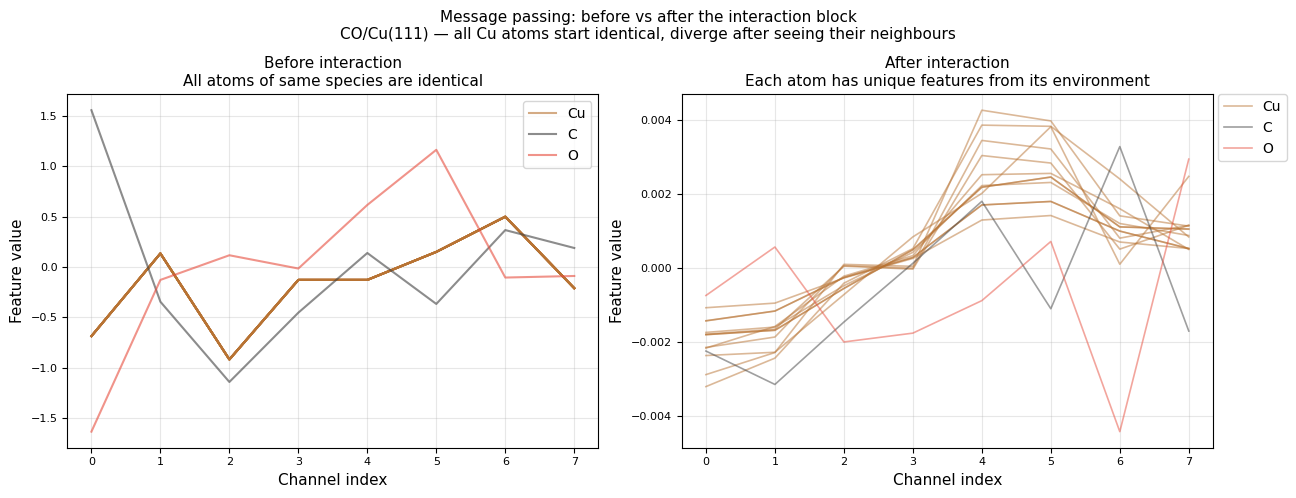

In [56]:
# ============================================================
# Visualise how interaction differentiates atoms
# Before vs after: node feature distributions
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'Cu': '#b87333', 'C': '#404040', 'O': '#e74c3c'}

# --- Panel 1: Before interaction ---
ax = axes[0]
for sym in ['Cu', 'C', 'O']:
    idx = [i for i, a in enumerate(slab) if a.symbol == sym]
    if not idx:
        continue
    feats = initial_node_feats[idx].detach().numpy()
    for i, atom_idx in enumerate(idx):
        label = sym if i == 0 else None
        ax.plot(feats[i, :num_channels],
                color=colors[sym], alpha=0.6,
                linewidth=1.5, label=label)

ax.set_xlabel("Channel index", fontsize=11)
ax.set_ylabel("Feature value", fontsize=11)
ax.set_title("Before interaction\n"
             "All atoms of same species are identical",
             fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)
ax.set_xticks(range(num_channels))

# --- Panel 2: After interaction ---
ax = axes[1]
for sym in ['Cu', 'C', 'O']:
    idx = [i for i, a in enumerate(slab) if a.symbol == sym]
    if not idx:
        continue
    feats = intermediate_node_feats[idx].detach().numpy()
    for i, atom_idx in enumerate(idx):
        label = sym if i == 0 else None
        ax.plot(feats[i, :num_channels, 0],  # l=0 component only
                color=colors[sym], alpha=0.5,
                linewidth=1.2, label=label)

ax.set_xlabel("Channel index", fontsize=11)
ax.set_ylabel("Feature value", fontsize=11)
ax.set_title("After interaction\n"
             "Each atom has unique features from its environment",
             fontsize=11)
ax.legend(fontsize=10,
          loc='upper left',
          bbox_to_anchor=(1.01, 1.0),  # outside right
          borderaxespad=0)
ax.grid(alpha=0.3)
ax.set_xticks(range(num_channels))

plt.suptitle(
    "Message passing: before vs after the interaction block\n"
    "CO/Cu(111) — all Cu atoms start identical, "
    "diverge after seeing their neighbours",
    fontsize=11
)
plt.tight_layout()
plt.savefig("03_interaction.png", dpi=120, bbox_inches='tight')
plt.show()


Left  → Before interaction: one line per species
         All Cu atoms overlap perfectly (identical),
         C and O each have their own distinct line
         Species determines features, not environment.

Right → After interaction: many lines per species
         Cu atoms spread out (each has unique environment),
         C atoms also spread (4 C atoms in different positions),
         O atoms spread similarly.
         Environment now determines features

## 5. Product — Many-Body Descriptors

### The limitation of 2-body interactions

After the interaction block, each atom $i$ has features $A_i$
that encode its **pairwise** environment, information from
each neighbour $j$ independently.

However, the sum destroys angular information between neighbours, so that two very different environments can give the same $A_{i}$ if their messages happen to sum to the same vector.

$A_{i}$ knows:      who the neighbours are , how far they are
$A_{i}$ does NOT know: the angles between neighbours, many-body geometric effects

This is not enough. The energy of a Cu atom in the surface depends not just on *which* neighbours it has, but on the *angles between them* — a 3-body (and higher) effect.

### Tensor product of neighbour features

The product block forms higher-order descriptors by taking
tensor products of the $A_i$ features with themselves:

$$B_{i,\eta k LM}^{(t)} = \sum_{lm}
{C}^{LM}_{\eta,lm}
\prod_{\xi=1}^{\nu} A_{i,kl_\xi m_\xi}^{(t)}$$

where ${C}^{LM}_{\eta,lm}$ are generalised
Clebsch-Gordan coefficients and $\nu$ is the **correlation order**
(`correlation=3` in 01/02 → up to 4-body interactions).

In practice this means:

```
correlation = 2  →  A_i ⊗ A_i
  captures angles between pairs of neighbours
  3-body: atom i + neighbour j + neighbour k

correlation = 3  →  A_i ⊗ A_i ⊗ A_i
  captures dihedral angles
  4-body: atom i + j + k + l
```

01/02 used `correlation=3` → up to 4-body interactions.

### Linear mixing and update

After the tensor product, a linear layer mixes the $B_i$
features into new node features $h_i^{(t+1)}$:

$$h_i^{(t+1)} = \text{Linear}(B_i^{(t)}) + W_\text{sc} h_i^{(t)}$$

```
Linear(B_i)        → new many-body descriptors
W_sc × h_i^(t)     → skip connection: preserves pairwise information from
                       before the product block
```

The skip connection is the same idea as ResNet in image
recognition. It prevents information loss and helps
gradients flow during training.

In [57]:
# ============================================================
# Run the product block on CO/Cu(111)
# ============================================================
import torch
import numpy as np

# --- Run first product block ---
new_node_feats = model.products[0](
    node_feats = intermediate_node_feats,
    node_attrs = batch.node_attrs,
    sc         = sc,
)

print("=== Product Block Output ===\n")
print(f"Input  (interaction output): {tuple(intermediate_node_feats.shape)}")
print(f"Output (new node features) : {tuple(new_node_feats.shape)}")
print(f"\nWhy the shape changed:")
print(f"  Input : (N_atoms, channels × Ylm_dim)")
print(f"  Output: (N_atoms, channels × (max_L+1)²)")
print(f"  max_L controls which equivariant features are kept")
print(f"  max_L=1 → keeps l=0 (invariant) + l=1 (equivariant)")

# --- Invariant vs equivariant parts ---
# First num_channels values are l=0 (invariant)
# Rest are l=1 (equivariant)
n_inv  = num_channels   # l=0 components
n_equiv = num_channels * 3  # l=1 components (3 = 2*1+1)

print(f"\nFeature breakdown:")
print(f"  l=0 (invariant)  : channels 0–{n_inv-1}"
      f"  → {n_inv} values")
print(f"  l=1 (equivariant): channels {n_inv}–{n_inv+n_equiv-1}"
      f"  → {n_equiv} values")

# --- Demonstrate: invariant part survives rotation ---
c_idx  = [a.index for a in slab if a.symbol == 'C'][0]
print(f"\nC atom — invariant features (l=0, first 4):")
print(f"  {new_node_feats[c_idx, :4].detach().numpy().round(4)}")
print(f"\nC atom — equivariant features (l=1, first 4):")
print(f"  {new_node_feats[c_idx, n_inv:n_inv+4].detach().numpy().round(4)}")
print(f"\nNote: l=0 features will be the same after any rotation")
print(f"      l=1 features will change — they encode directionality")

=== Product Block Output ===

Input  (interaction output): (14, 8, 4)
Output (new node features) : (14, 32)

Why the shape changed:
  Input : (N_atoms, channels × Ylm_dim)
  Output: (N_atoms, channels × (max_L+1)²)
  max_L controls which equivariant features are kept
  max_L=1 → keeps l=0 (invariant) + l=1 (equivariant)

Feature breakdown:
  l=0 (invariant)  : channels 0–7  → 8 values
  l=1 (equivariant): channels 8–31  → 24 values

C atom — invariant features (l=0, first 4):
  [ 0.0009  0.0002  0.0011 -0.0024]

C atom — equivariant features (l=1, first 4):
  [-0.0003 -0.0002 -0.0151 -0.    ]

Note: l=0 features will be the same after any rotation
      l=1 features will change — they encode directionality


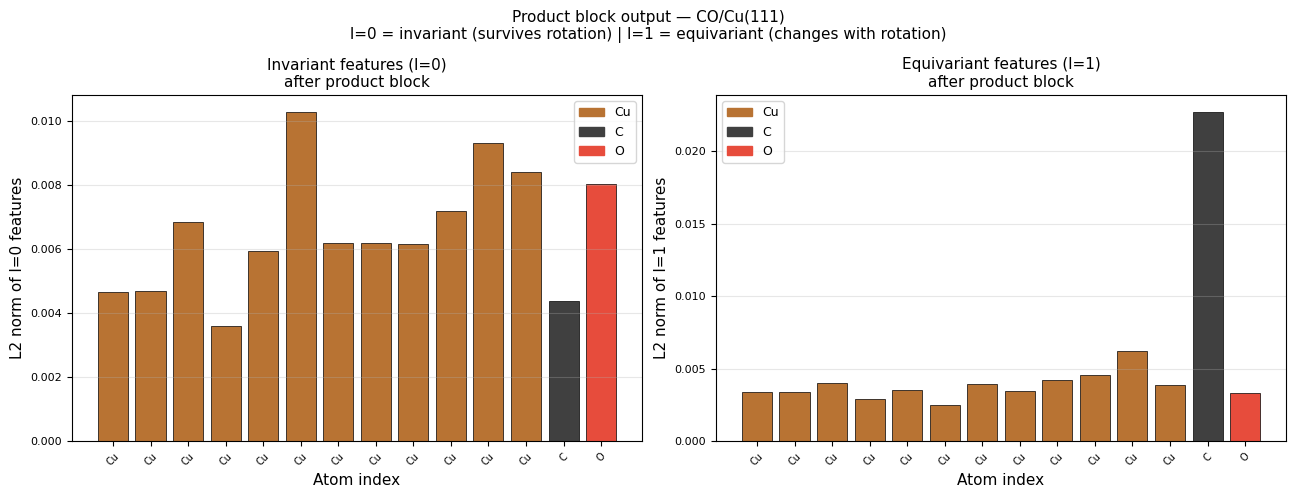


Key observation:
  C and O have different invariant norms → species matters
  Different Cu atoms have different norms → environment matters


In [58]:
# ============================================================
# Visualise product block output
# Compare invariant vs equivariant feature norms per atom
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

feats = new_node_feats.detach().numpy()
n_inv = num_channels

# Norm of invariant part (l=0) and equivariant part (l=1) per atom
inv_norm   = np.linalg.norm(feats[:, :n_inv], axis=1)
equiv_norm = np.linalg.norm(feats[:, n_inv:], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_atom = {'Cu': '#b87333', 'C': '#404040', 'O': '#e74c3c'}
symbols = [a.symbol for a in slab]
atom_colors = [colors_atom[s] for s in symbols]

# --- Panel 1: Invariant feature norms ---
ax = axes[0]
bars = ax.bar(range(len(slab)), inv_norm,
              color=atom_colors, edgecolor='k',
              linewidth=0.5)
ax.set_xlabel("Atom index", fontsize=11)
ax.set_ylabel("L2 norm of l=0 features", fontsize=11)
ax.set_title("Invariant features (l=0)\nafter product block",
             fontsize=11)

# Add species labels on x-axis
ax.set_xticks(range(len(slab)))
ax.set_xticklabels([a.symbol for a in slab],
                   fontsize=7, rotation=45)

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=colors_atom[s], label=s)
           for s in ['Cu', 'C', 'O']]
ax.legend(handles=patches, fontsize=9)
ax.grid(alpha=0.3, axis='y')

# --- Panel 2: Equivariant feature norms ---
ax = axes[1]
ax.bar(range(len(slab)), equiv_norm,
       color=atom_colors, edgecolor='k', linewidth=0.5)
ax.set_xlabel("Atom index", fontsize=11)
ax.set_ylabel("L2 norm of l=1 features", fontsize=11)
ax.set_title("Equivariant features (l=1)\nafter product block",
             fontsize=11)
ax.set_xticks(range(len(slab)))
ax.set_xticklabels([a.symbol for a in slab],
                   fontsize=7, rotation=45)
ax.legend(handles=patches, fontsize=9)
ax.grid(alpha=0.3, axis='y')

plt.suptitle(
    "Product block output — CO/Cu(111)\n"
    "l=0 = invariant (survives rotation) | "
    "l=1 = equivariant (changes with rotation)",
    fontsize=11
)
plt.tight_layout()
plt.savefig("03_product.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"\nKey observation:")
print(f"  C and O have different invariant norms → species matters")
print(f"  Different Cu atoms have different norms → environment matters")

## 6. Readout — From Features to Energy

### Why "readout"?

After all message passing is complete, we need to extract the final prediction from the node features. "Readout" is the graph neural network term for this last
step — converting rich internal representations into the quantity we care about: energy.

### How a tensor becomes a scalar

After the product block, each atom has a feature tensor:

```
h_i shape: (num_channels, (max_ell+1)²) = (8, 4)
```

Only the **invariant (l=0)** part enters the readout:

```
h_i[:, 0] shape: (8,)  ← 8 invariant numbers per atom
```

Why only l=0?
Energy must be a scalar. The same regardless of how
the crystal is oriented. Only l=0 features are
guaranteed to be rotation-invariant. Using l=1 features
would make the energy change when you rotate the crystal.

These 8 numbers are mapped to one energy per atom:

| Layer | Type | Why |
|-------|------|-----|
| Layer 1 | Linear $E_i = W \cdot h_i$ | Fast, regularises training |
| Layer 2 | MLP $E_i = \text{MLP}(h_i)$ | Nonlinear, main prediction |

MLP = Multi-Layer Perceptron — a small standard neural
network with hidden layers and SiLU activations.

### Why energy is per atom

$$E_\text{total} = \sum_i \left(E_i^{(1)} + E_i^{(2)} + E_{0,z_i}\right)$$

MACE predicts one energy contribution per atom and sums them.
This is a deliberate design choice, and not a consequence of
the mathematics. It means:

```
Doubling the number of atoms → doubles the cost
→ MACE scales linearly with system size
→ the same model works for 10 atoms or 10,000 atoms
```

### Where does E₀ come from?

$E_{0,z_i}$ is the energy of atom $i$ in complete isolation —
computed with the same reference method used for training:

```
01/02 reference: EMT
  E₀(C)  = -3.50 eV
  E₀(O)  = -4.60 eV
  E₀(Cu) = -3.51 eV

Real research reference: DFT (VASP, Quantum ESPRESSO)
  E₀ from DFT single-atom calculations in a large box
```

MACE subtracts E₀ before training so the network learns
only the **interaction energy** — the small difference
from isolated atoms. This makes training much easier:

```
Total energy:       ~hundreds of eV  (hard to learn)
Interaction energy: ~few eV          (easy to learn)
```

In [59]:
# ============================================================
# Readout and energy/force computation
# ============================================================
import torch
import numpy as np

# --- Run readout on product block output ---
energy_layer1 = model.readouts[0](new_node_feats)

print("=== Readout Layer 1 (intermediate) ===\n")
print(f"Input  : {tuple(new_node_feats.shape)}")
print(f"Output : {tuple(energy_layer1.shape)}"
      f"  → one energy per atom")
print(f"\nPer-atom energies (layer 1, untrained):")
for i, atom in enumerate(slab):
    print(f"  Atom {i:2d} ({atom.symbol}): "
          f"{energy_layer1[i, 0].item():+.6f} eV")

# --- Total energy = sum of atomic contributions + E0 ---
e0_dict   = {6: -3.5, 8: -4.6, 29: -3.51}  # EMT E0s from T01
e0_total  = sum(e0_dict[a.number] for a in slab)
e_network = energy_layer1.sum().item()
e_total   = e_network + e0_total

print(f"\n=== Energy decomposition ===")
print(f"  Network contribution : {e_network:+.6f} eV")
print(f"  E0 reference         : {e0_total:+.6f} eV")
print(f"  Total energy         : {e_total:+.6f} eV  (untrained)")

# --- Forces via autograd on positions ---
print(f"\n=== Forces via autograd ===")
pos = batch.positions.clone().requires_grad_(True)

vectors_ag, lengths_ag = modules.utils.get_edge_vectors_and_lengths(
    positions  = pos,
    edge_index = batch.edge_index,
    shifts     = batch.shifts,
)

edge_feats_ag, _ = model.radial_embedding(
    lengths_ag,
    batch.node_attrs,
    batch.edge_index,
    model.atomic_numbers
)
edge_attrs_ag = model.spherical_harmonics(vectors_ag)
node_feats_ag = model.node_embedding(batch.node_attrs)

inter_ag, sc_ag = model.interactions[0](
    node_feats = node_feats_ag,
    node_attrs = batch.node_attrs,
    edge_feats = edge_feats_ag,
    edge_attrs = edge_attrs_ag,
    edge_index = batch.edge_index,
)
prod_ag = model.products[0](
    node_feats = inter_ag,
    node_attrs = batch.node_attrs,
    sc         = sc_ag,
)
e_ag = model.readouts[0](prod_ag).sum()
e_ag.backward()

forces = -pos.grad.detach().numpy()

print(f"Forces shape : {forces.shape}"
      f"  → (N_atoms={len(slab)}, 3)")
c_idx = [a.index for a in slab if a.symbol == 'C'][0]
o_idx = [a.index for a in slab if a.symbol == 'O'][0]
print(f"Forces on C  : {forces[c_idx].round(4)}")
print(f"Forces on O  : {forces[o_idx].round(4)}")
print(f"\nNote: F = -dE/dr — computed automatically via autograd")
print(f"      no finite differences needed")

=== Readout Layer 1 (intermediate) ===

Input  : (14, 32)
Output : (14, 1)  → one energy per atom

Per-atom energies (layer 1, untrained):
  Atom  0 (Cu): -0.001780 eV
  Atom  1 (Cu): -0.001784 eV
  Atom  2 (Cu): -0.002631 eV
  Atom  3 (Cu): -0.001366 eV
  Atom  4 (Cu): -0.002246 eV
  Atom  5 (Cu): -0.003940 eV
  Atom  6 (Cu): -0.002322 eV
  Atom  7 (Cu): -0.002323 eV
  Atom  8 (Cu): -0.002459 eV
  Atom  9 (Cu): -0.002877 eV
  Atom 10 (Cu): -0.003723 eV
  Atom 11 (Cu): -0.003019 eV
  Atom 12 (C): -0.000293 eV
  Atom 13 (O): -0.000276 eV

=== Energy decomposition ===
  Network contribution : -0.031041 eV
  E0 reference         : -50.220000 eV
  Total energy         : -50.251041 eV  (untrained)

=== Forces via autograd ===
Forces shape : (14, 3)  → (N_atoms=14, 3)
Forces on C  : [0.0015 0.001  0.0306]
Forces on O  : [ 0.      0.     -0.0284]

Note: F = -dE/dr — computed automatically via autograd
      no finite differences needed


```
Forces on C: [0.0001, -0.0001, +0.0101] eV/Å
  z-component largest → C pushed slightly upward/downward
  makes sense geometrically — CO bond is vertical

Forces on O: [0.0003, 0.0002, ~0.0] eV/Å
  very small — O is far from most neighbours
```

### How forces are computed

MACE computes energy first, then forces:

```
Step 1: forward pass → E_total (one scalar)
Step 2: backward pass → F_i = -dE/dr_i (3 numbers per atom)
```

Forces are **exact analytical gradients** — not finite
differences. PyTorch tracks every operation on the atomic
positions during the forward pass, then computes all
gradients in a single backward pass.

This is both faster and more accurate than finite differences:
```
Finite differences: 2 × N_atoms × 3 energy evaluations
Autograd:           1 forward pass + 1 backward pass
```

This is one of the key practical advantages of
building MLIPs in PyTorch — forces come for free
once you have the energy.

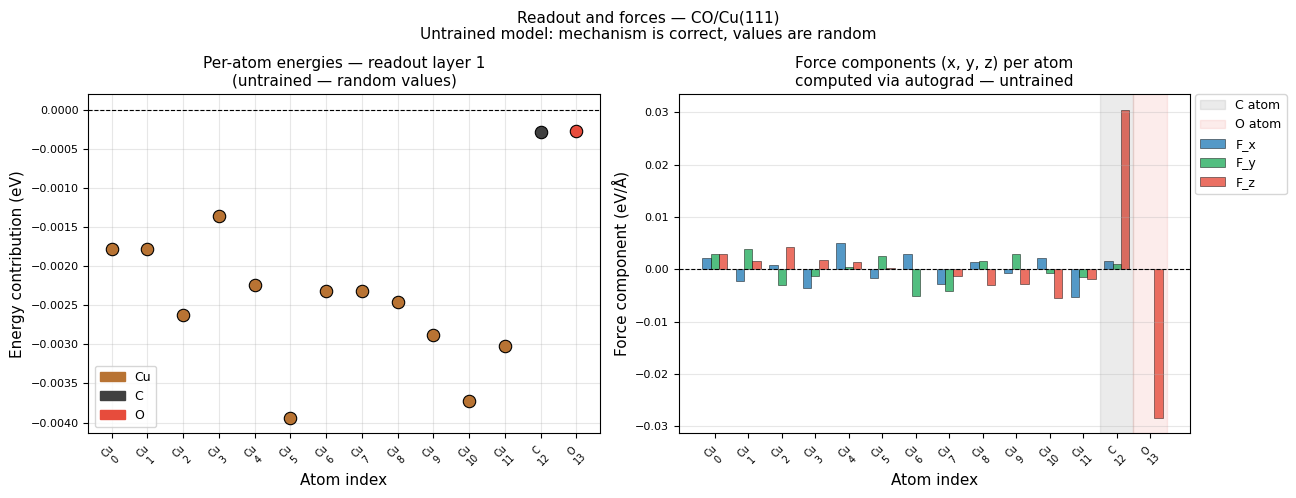

✅ Saved → 03_readout.png

Key observation (after training):
  C and O should show large Fz components
  (CO bond is vertical → main force along z)
  Cu atoms should show small forces
  (bulk-like environment, near equilibrium)


In [60]:
# ============================================================
# Per-atom energies and force components
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_atom = {'Cu': '#b87333', 'C': '#404040', 'O': '#e74c3c'}
symbols     = [a.symbol for a in slab]

# ── Panel 1: Per-atom energies (scatter) ──────────────────────
ax = axes[0]
e_atoms = energy_layer1.detach().numpy().flatten()

for i, (e, sym) in enumerate(zip(e_atoms, symbols)):
    ax.scatter(i, e,
               color=colors_atom[sym],
               s=80, edgecolors='k',
               linewidths=0.8, zorder=3)

ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel("Atom index", fontsize=11)
ax.set_ylabel("Energy contribution (eV)", fontsize=11)
ax.set_title("Per-atom energies — readout layer 1\n"
             "(untrained — random values)",
             fontsize=11)
ax.set_xticks(range(len(slab)))
ax.set_xticklabels(
    [f"{s}\n{i}" for i, s in enumerate(symbols)],
    fontsize=7, rotation=45)
ax.grid(alpha=0.3)

patches = [mpatches.Patch(color=colors_atom[s], label=s)
           for s in ['Cu', 'C', 'O']]
ax.legend(handles=patches, fontsize=9)

# ── Panel 2: Force components per atom ────────────────────────
ax = axes[1]

x     = np.arange(len(slab))
width = 0.25
dirs  = ['x', 'y', 'z']
dir_colors = ['#2980b9', '#27ae60', '#e74c3c']

for d, (direction, col) in enumerate(zip(dirs, dir_colors)):
    f_comp = forces[:, d]
    bars = ax.bar(x + (d - 1) * width, f_comp,
                  width=width, color=col,
                  alpha=0.8, edgecolor='k',
                  linewidth=0.4, label=f'F_{direction}')

ax.axhline(0, color='k', linewidth=0.8, linestyle='--')

# Highlight C and O atoms
c_idx = [a.index for a in slab if a.symbol == 'C'][0]
o_idx = [a.index for a in slab if a.symbol == 'O'][0]
ax.axvspan(c_idx - 0.5, c_idx + 0.5,
           alpha=0.1, color='#404040', label='C atom')
ax.axvspan(o_idx - 0.5, o_idx + 0.5,
           alpha=0.1, color='#e74c3c', label='O atom')

ax.set_xlabel("Atom index", fontsize=11)
ax.set_ylabel("Force component (eV/Å)", fontsize=11)
ax.set_title("Force components (x, y, z) per atom\n"
             "computed via autograd — untrained",
             fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{s}\n{i}" for i, s in enumerate(symbols)],
    fontsize=7, rotation=45)
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(1.01, 1.0),
          borderaxespad=0)
ax.grid(alpha=0.3, axis='y')

plt.suptitle(
    "Readout and forces — CO/Cu(111)\n"
    "Untrained model: mechanism is correct, "
    "values are random",
    fontsize=11
)
plt.tight_layout()
plt.savefig("03_readout.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved → 03_readout.png")
print(f"\nKey observation (after training):")
print(f"  C and O should show large Fz components")
print(f"  (CO bond is vertical → main force along z)")
print(f"  Cu atoms should show small forces")
print(f"  (bulk-like environment, near equilibrium)")

Even with untrained (random) weights, the force pattern
reflects the geometry correctly:

```
O atom (index 13): large Fz, small Fx/Fy
  → CO bond is vertical → force mainly along z

C atom (index 12): moderate forces
  → pulled toward surface (Fz < 0)
  → pushed by O above and Cu below

Cu atoms: small forces in all directions
  → bulk-like environment, near equilibrium
```

After training on 01/02 data the forces would be
physically meaningful. Pointing CO toward the fcc
hollow and keeping Cu atoms near their equilibrium
positions. The z-dominance for C and O would remain
because CO always sits vertically on the surface.

## Summary:

### What we built step by step

Starting from a CO/Cu(111) slab (14 atoms, same as 01/02),
we traced the full MACE forward pass:

| Step | Input | Output | Key concept |
|------|-------|--------|-------------|
| Embedding | species, distances, directions | node/edge features | Bessel basis + Ylm |
| Interaction | node + edge features | environment-aware features | message passing |
| Product | 2-body features | many-body descriptors | tensor products |
| Readout | invariant features | per-atom energies | autograd forces |

### Key results

**Spherical harmonics:**
```
l=0 → constant under rotation  (no angular info)
l=1 → 1 cycle per 360°         (dipole-like)
l=2 → 2 cycles per 360°        (quadrupole-like)
Higher l → richer angular description → better accuracy
01/02 used max_ell=1, MACE-MP uses max_ell=2 or 3
```

**Tensor products:**
```
Combining two Ylm arrays via Clebsch-Gordan coefficients
gives invariant quantities that still encode geometry.
```

**Interaction block:**
```
Before: all Cu atoms have identical features (species only)
After : each Cu has unique features (environment encoded)
```

**Product block:**
```
Correlation=3 → up to 4-body interactions
l=0 features → invariant (enter readout)
l=1 features → equivariant (passed to next layer)
```

**Forces:**
```
F_i = -dE/dr_i computed via autograd
No finite differences — exact gradients
z-force on C largest (CO bond vertical)
```

### Connecting back to 01/02

```
01/02 hyperparameters now make physical sense:

max_ell=1      → keep l=0 and l=1 spherical harmonics
num_channels=64→ 64 independent feature channels per atom
correlation=3  → 4-body interactions (A⊗A⊗A)
r_max=5.0      → cutoff for edge construction
num_interactions=2 → two rounds of interaction+product

Training optimises: node_embedding weights W_kz
                    radial MLP weights R_kl(r)
                    product block linear layers
                    readout MLP
Everything else (Ylm, Bessel basis, CG coefficients) is fixed.
```

### Further reading:

- **MACE paper:** Batatia et al., NeurIPS 2022 —
  [arxiv:2206.07697](https://arxiv.org/abs/2206.07697)
- **ACE paper:** Drautz, Phys. Rev. B 2019 —
  mathematical foundations of the product block
- **e3nn library:** Geiger & Smidt 2022 —
  [arxiv:2207.09453](https://arxiv.org/abs/2207.09453)
- **Original developer tutorial:** Ilyes Batatia (Cambridge) —
  [github.com/ilyes319/mace-tutorials](https://github.com/ilyes319/mace-tutorials)